In [4]:
import os
import numpy as np
import trimesh

# ==========================================================
# INPUT / OUTPUT FOLDERS
# ==========================================================

input_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Dataset\Experimental Data\11 landmarks\sorted_mrk\rbf_registered_meshes_Method_B"

output_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\dummy"

os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# VOXELIZATION SETTINGS
# ==========================================================

PITCH = 1.0  # mm

# ==========================================================
# GET STL FILES
# ==========================================================

stl_files = sorted(
    [
        f for f in os.listdir(input_folder)
        if f.lower().endswith(".stl")
    ],
    key=lambda x: int(x.split("_")[-1].split(".")[0])
)

print(f"Found {len(stl_files)} STL files.\n")

# ==========================================================
# PROCESS EACH SYNTHETIC FEMUR
# ==========================================================

for idx, filename in enumerate(stl_files, start=1):

    print("=" * 60)
    print(f"{idx}/{len(stl_files)} : {filename}")

    mesh_path = os.path.join(input_folder, filename)

    mesh = trimesh.load(mesh_path, process=True)

    # ------------------------------------------------------
    # Sanity check
    # ------------------------------------------------------

    if not mesh.is_watertight:
        print("WARNING: Mesh is not watertight!")

    # ------------------------------------------------------
    # Voxelize
    # ------------------------------------------------------

    voxel_grid = mesh.voxelized(pitch=PITCH)

    # Fill interior
    voxel_grid = voxel_grid.fill()

    voxel_matrix = voxel_grid.matrix.astype(bool)

    # ------------------------------------------------------
    # Save voxel matrix
    # ------------------------------------------------------

    save_path = os.path.join(
        output_folder,
        f"synthetic_femur_{idx}.npy"
    )

    np.save(save_path, voxel_matrix)

    # ------------------------------------------------------
    # Diagnostics
    # ------------------------------------------------------

    occupied = voxel_matrix.sum()
    total = voxel_matrix.size

    print(f"Shape       : {voxel_matrix.shape}")
    print(f"Occupied    : {occupied}")
    print(f"Occupancy   : {occupied/total:.4f}")

print("\n========================================")
print("Finished voxelizing all synthetic femurs.")
print("========================================")

Found 16 STL files.

1/16 : Warped_femur_01.stl
Shape       : (78, 90, 170)
Occupied    : 155119
Occupancy   : 0.1300
2/16 : Warped_femur_02.stl
Shape       : (86, 117, 240)
Occupied    : 215663
Occupancy   : 0.0893
3/16 : Warped_femur_03.stl
Shape       : (81, 84, 160)
Occupied    : 155981
Occupancy   : 0.1433
4/16 : Warped_femur_04.stl
Shape       : (73, 76, 151)
Occupied    : 24755
Occupancy   : 0.0295
5/16 : Warped_femur_05.stl
Shape       : (86, 102, 192)
Occupied    : 195818
Occupancy   : 0.1163
6/16 : Warped_femur_06.stl
Shape       : (87, 105, 212)
Occupied    : 184272
Occupancy   : 0.0952
7/16 : Warped_femur_07.stl
Shape       : (80, 89, 176)
Occupied    : 159440
Occupancy   : 0.1272
8/16 : Warped_femur_08.stl
Shape       : (82, 98, 204)
Occupied    : 173623
Occupancy   : 0.1059
9/16 : Warped_femur_09.stl
Shape       : (81, 80, 158)
Occupied    : 137331
Occupancy   : 0.1341
10/16 : Warped_femur_10.stl
Shape       : (92, 115, 256)
Occupied    : 219518
Occupancy   : 0.0810
11/16

Shape: (78, 90, 170)
Occupied voxels: 155119


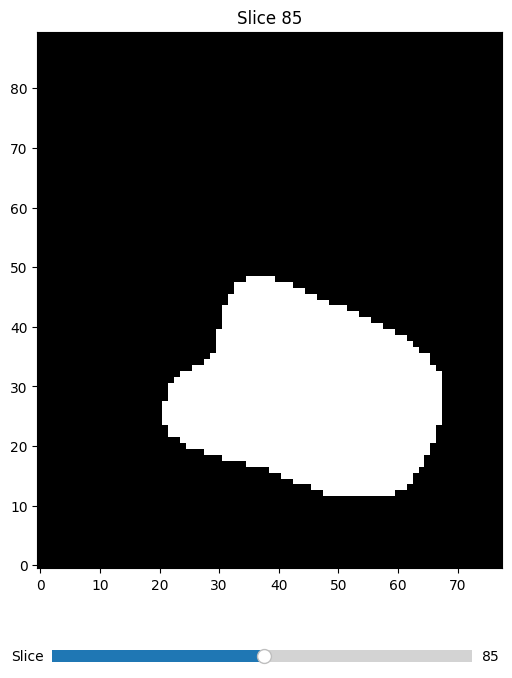

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

# ======================================================
# Load voxel matrix
# ======================================================

voxel_path = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\dummy\synthetic_femur_1.npy"

voxel_matrix = np.load(voxel_path)

print("Shape:", voxel_matrix.shape)
print("Occupied voxels:", voxel_matrix.sum())

# ======================================================
# Initial slice
# ======================================================

initial_slice = voxel_matrix.shape[2] // 2

fig, ax = plt.subplots(figsize=(6, 8))
plt.subplots_adjust(bottom=0.20)

img = ax.imshow(
    voxel_matrix[:, :, initial_slice].T,
    cmap="gray",
    origin="lower"
)

ax.set_title(f"Slice {initial_slice}")

# ======================================================
# Slider
# ======================================================

slider_ax = plt.axes([0.15, 0.08, 0.70, 0.03])

slider = Slider(
    ax=slider_ax,
    label="Slice",
    valmin=0,
    valmax=voxel_matrix.shape[2]-1,
    valinit=initial_slice,
    valstep=1
)

# ======================================================
# Update function
# ======================================================

def update(val):

    s = int(slider.val)

    img.set_data(
        voxel_matrix[:, :, s].T
    )

    ax.set_title(f"Slice {s}")

    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()

In [3]:
import os
import numpy as np
import torch
import imageio.v2 as imageio
from tqdm import tqdm

# ==========================================================
# INPUT / OUTPUT
# ==========================================================

input_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\dummy"

output_folder = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\dummy\pngs"

os.makedirs(output_folder, exist_ok=True)

# ==========================================================
# GEOMETRY (LOCKED PARAMETERS)
# ==========================================================

VOXEL_PITCH = 1.0      # mm
SDD = 1000.0           # Source-to-detector distance (mm)
SOD = 800.0            # Source-to-object distance (mm)
PIXEL_SPACING = 1.1481 # mm
OUTPUT_SIZE = (256,256)
AP_AXIS = 1            # Y-axis

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", DEVICE)

# ==========================================================
# CONE BEAM PROJECTOR
# ==========================================================

def cone_beam_project_torch(volume,
                            voxel_pitch,
                            sdd,
                            sod,
                            pixel_spacing,
                            output_size=(256,256),
                            ap_axis=1,
                            device='cuda'):

    with torch.no_grad():

        vol = torch.as_tensor(
            volume,
            dtype=torch.float32,
            device=device
        )

        vol_shape = torch.tensor(
            vol.shape,
            dtype=torch.float32,
            device=device
        )

        vol_center = vol_shape / 2.0

        H, W = output_size

        other_axes = [i for i in range(3) if i != ap_axis]

        # --------------------------------------------------
        # Source
        # --------------------------------------------------

        source = torch.zeros(3, device=device)

        source[ap_axis] = -sod / voxel_pitch

        # --------------------------------------------------
        # Detector
        # --------------------------------------------------

        rows = torch.arange(
            H,
            device=device,
            dtype=torch.float32
        )

        cols = torch.arange(
            W,
            device=device,
            dtype=torch.float32
        )

        det_v = (
            (rows - H/2 + 0.5)
            * pixel_spacing
            / voxel_pitch
        )

        det_u = (
            (cols - W/2 + 0.5)
            * pixel_spacing
            / voxel_pitch
        )

        det_pos = torch.zeros(
            H,
            W,
            3,
            device=device
        )

        det_pos[:,:,ap_axis] = (
            (sdd-sod)
            / voxel_pitch
        )

        det_pos[:,:,other_axes[0]] = det_u.view(1,W)

        det_pos[:,:,other_axes[1]] = det_v.view(H,1)

        # --------------------------------------------------
        # Rays
        # --------------------------------------------------

        ray_vec = det_pos-source.view(1,1,3)

        ray_length = torch.norm(
            ray_vec,
            dim=-1,
            keepdim=True
        )

        ray_dir = ray_vec/ray_length

        max_length = ray_length.max().item()

        num_samples = int(max_length*1.2)

        t_vals = torch.linspace(
            0,
            max_length,
            num_samples,
            device=device
        )

        positions = (
            source.view(1,1,1,3)
            + t_vals.view(1,1,-1,1)
            * ray_dir.unsqueeze(2)
            + vol_center.view(1,1,1,3)
        )

        norm_pos = torch.empty_like(positions)

        norm_pos[...,0] = (
            positions[...,2]
            /(vol.shape[2]-1)
            *2
            -1
        )

        norm_pos[...,1] = (
            positions[...,1]
            /(vol.shape[1]-1)
            *2
            -1
        )

        norm_pos[...,2] = (
            positions[...,0]
            /(vol.shape[0]-1)
            *2
            -1
        )

        grid = norm_pos.view(
            1,
            H,
            W*num_samples,
            1,
            3
        )

        vol5d = vol.view(
            1,
            1,
            vol.shape[0],
            vol.shape[1],
            vol.shape[2]
        )

        sampled = torch.nn.functional.grid_sample(
            vol5d,
            grid,
            mode='bilinear',
            padding_mode='zeros',
            align_corners=True
        )

        sampled = sampled.view(
            H,
            W,
            num_samples
        )

        drr = sampled.sum(dim=-1)

        return drr.cpu().numpy()

# ==========================================================
# PROCESS ALL VOXELS
# ==========================================================

files = sorted(
    [
        f for f in os.listdir(input_folder)
        if f.endswith(".npy")
    ],
    key=lambda x:int(
        x.split("_")[-1].split(".")[0]
    )
)

print("Number of volumes:",len(files))

for idx,file in enumerate(tqdm(files),start=1):

    volume = np.load(
        os.path.join(input_folder,file)
    )

    drr = cone_beam_project_torch(
        volume,
        voxel_pitch=VOXEL_PITCH,
        sdd=SDD,
        sod=SOD,
        pixel_spacing=PIXEL_SPACING,
        output_size=OUTPUT_SIZE,
        ap_axis=AP_AXIS,
        device=DEVICE
    )

    # ------------------------------------------
    # Normalize to 0-255
    # ------------------------------------------

    drr -= drr.min()

    drr /= (
        drr.max()+1e-8
    )

    drr = (
        drr*255
    ).astype(np.uint8)

    imageio.imwrite(
        os.path.join(
            output_folder,
            f"synthetic_femur_{idx}.png"
        ),
        drr
    )

print("\nFinished generating all DRRs.")

Using device: cuda
Number of volumes: 16


100%|██████████| 16/16 [00:03<00:00,  4.42it/s]


Finished generating all DRRs.


In [6]:
import torch
import timm
from PIL import Image
from torchvision import transforms

# ==========================================================
# DEVICE
# ==========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ==========================================================
# LOAD MODEL
# ==========================================================

model = timm.create_model(
    "xception",
    pretrained=False,
    num_classes=5
)

model.load_state_dict(
    torch.load(
        r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\best_xception_model.pth",
        map_location=device
    )
)

model = model.to(device)
model.eval()

print("Model loaded.")

# ==========================================================
# PREPROCESSING
# ==========================================================

transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ==========================================================
# LOAD IMAGE
# ==========================================================

image_path = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\dummy\pngs\synthetic_femur_2.png"   # <-- change this

image = Image.open(image_path)

image = transform(image)

image = image.unsqueeze(0)          # (1,3,256,256)

image = image.to(device)

# ==========================================================
# PREDICT
# ==========================================================

with torch.no_grad():

    prediction = model(image)

prediction = prediction.squeeze().cpu().numpy()

# ==========================================================
# PRINT RESULTS
# ==========================================================

print("\nPredicted deformation parameters:\n")

for i, value in enumerate(prediction, start=1):
    print(f"p{i} = {value:.6f}")

Model loaded.

Predicted deformation parameters:

p1 = 1.883548
p2 = -0.986669
p3 = 1.008656
p4 = 1.139304
p5 = 0.727416


In [1]:
import trimesh
import numpy as np
from scipy.spatial import cKDTree

# ==========================================================
# LOAD STL FILES
# ==========================================================

GT_PATH = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\Dataset\Experimental Data\11 landmarks\sorted_mrk\rbf_registered_meshes_Method_B\Warped_femur_12.stl"
PRED_PATH = r"C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\test_femur.stl"

gt_mesh = trimesh.load(GT_PATH, process=True)
pred_mesh = trimesh.load(PRED_PATH, process=True)

# ==========================================================
# BASIC CHECKS
# ==========================================================

assert gt_mesh.vertices.shape == pred_mesh.vertices.shape, \
    "Meshes have different numbers of vertices."

assert gt_mesh.faces.shape == pred_mesh.faces.shape, \
    "Meshes have different topology."

print("Vertices :", gt_mesh.vertices.shape[0])
print("Faces    :", gt_mesh.faces.shape[0])

# ==========================================================
# METRIC 1
# Mean Vertex Error (Lower is better)
# Average distance between corresponding vertices.
# ==========================================================

vertex_errors = np.linalg.norm(
    gt_mesh.vertices - pred_mesh.vertices,
    axis=1
)

mve = np.mean(vertex_errors)

# ==========================================================
# METRIC 2
# RMSE (Lower is better)
# Penalizes large local errors.
# ==========================================================

rmse = np.sqrt(np.mean(vertex_errors**2))

# ==========================================================
# METRIC 3
# Maximum Vertex Error (Lower is better)
# Worst pointwise error on the surface.
# ==========================================================

max_error = np.max(vertex_errors)

# ==========================================================
# METRIC 4
# Hausdorff Distance (Lower is better)
# Maximum nearest-neighbor distance between surfaces.
# ==========================================================

tree_gt = cKDTree(gt_mesh.vertices)
tree_pred = cKDTree(pred_mesh.vertices)

dist_gt_to_pred, _ = tree_pred.query(gt_mesh.vertices)
dist_pred_to_gt, _ = tree_gt.query(pred_mesh.vertices)

hausdorff = max(
    dist_gt_to_pred.max(),
    dist_pred_to_gt.max()
)

# ==========================================================
# METRIC 5
# Chamfer Distance (Lower is better)
# Average bidirectional surface distance.
# ==========================================================

chamfer = (
    np.mean(dist_gt_to_pred**2)
    +
    np.mean(dist_pred_to_gt**2)
)

# ==========================================================
# PRINT RESULTS
# ==========================================================

print("\n================ Evaluation ================\n")

print(f"Mean Vertex Error (mm) : {mve:.4f}")
print("  Lower is better (0 = perfect)\n")

print(f"RMSE (mm)              : {rmse:.4f}")
print("  Lower is better (This penalizes larger local errors.)\n")

print(f"Maximum Error (mm)     : {max_error:.4f}")
print("  Lower is better (This tells you the worst reconstruction location.)\n")

print(f"Hausdorff Distance (mm): {hausdorff:.4f}")
print("  Lower is better (Measures the largest distance between the two surfaces.)\n")

print(f"Chamfer Distance (mm²) : {chamfer:.4f}")
print("  Lower is better (Measures average bidirectional surface distance.)\n")

print("============================================")

Vertices : 24431
Faces    : 48718

================ Evaluation ================

Mean Vertex Error (mm) : 3.6445
  Lower is better (0 = perfect)

RMSE (mm)              : 3.9385
  Lower is better (This penalizes larger local errors.)

Maximum Error (mm)     : 8.7971
  Lower is better (This tells you the worst reconstruction location.)

Hausdorff Distance (mm): 8.7971
  Lower is better (Measures the largest distance between the two surfaces.)

Chamfer Distance (mm²) : 7.3363
  Lower is better (Measures average bidirectional surface distance.)



In [2]:
print(gt_mesh.vertices.shape)
print(pred_mesh.vertices.shape)
print(gt_mesh.faces.shape)

(24431, 3)
(24431, 3)
(48718, 3)


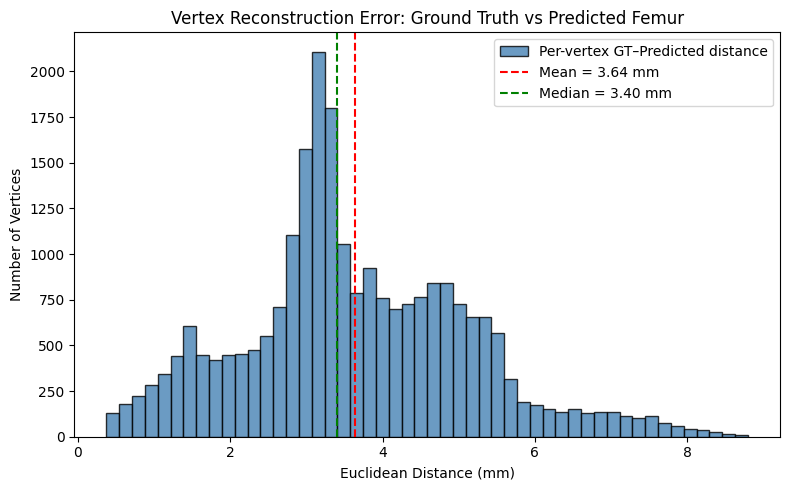

In [6]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))
plt.hist(vertex_errors, bins=50, color='steelblue', edgecolor='black', alpha=0.8,
         label='Per-vertex GT–Predicted distance')

plt.axvline(np.mean(vertex_errors), color='red', linestyle='--', linewidth=1.5,
            label=f'Mean = {np.mean(vertex_errors):.2f} mm')
plt.axvline(np.median(vertex_errors), color='green', linestyle='--', linewidth=1.5,
            label=f'Median = {np.median(vertex_errors):.2f} mm')

plt.title('Vertex Reconstruction Error: Ground Truth vs Predicted Femur')
plt.xlabel('Euclidean Distance (mm)')
plt.ylabel('Number of Vertices')
plt.legend()
plt.tight_layout()
plt.show()

In [1]:
import numpy as np
mean_shape=np.load(r'C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\ssm_basis\mean_shape.npy')

location1 =r'C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\ssm_basis\eigenvectors.npy'
data = np.load(location1)
eigenvectors = data[:5]

print("Mean Shape:",mean_shape.shape)
print()
# Print the array contents
print("Eigenvectors:",eigenvectors)

print()

location2 =r'C:\Users\Yash\OneDrive\Desktop\Nit Internship\Base paper Implementation\ssm_basis\sigma.npy'
data = np.load(location2)
sigma = data[:5]

# Print the array contents
print("Sigma values:",sigma)


Mean Shape: (73293,)

Eigenvectors: [[-0.00042662 -0.00240114 -0.00681031 ... -0.00042873  0.0022811
   0.01085113]
 [ 0.00333708 -0.00832499 -0.00391668 ... -0.0033604  -0.00070032
   0.00105163]
 [ 0.00725902  0.00401192 -0.00456556 ... -0.00179843 -0.01220611
  -0.00104283]
 [ 0.01019132 -0.00064115 -0.00095295 ...  0.0095454   0.01370144
   0.0043609 ]
 [ 0.0041367   0.00354933  0.00665366 ... -0.00879889 -0.00927068
  -0.0027694 ]]

Sigma values: [1853.54425145  405.83531725  307.3041873   247.18201026  177.58565124]
